# Sistema de suspensión del auto
<img src="https://drive.google.com/uc?export=view&id=13o8BWFvNQ3hMZKUs45B40p7HkKt78cm9" width="400">


Sistema de ecuaciones:
$$\"z_2 +\frac{k_1}{M}z_2 + \frac{c}{M}\.z_2-\frac{k_1}{M}z_1-\frac{c}{M}\.z_1 = g\$$
$$\"z_1 +\frac{k_1+k_2}{m}z_1 + \frac{c}{m}\.z_1-\frac{k_1}{m}z_2-\frac{c}{m}\.z_2 = g+\frac{k_2}{m}r$$

Parámetros:  
M = 300 kg      
m = 40 kg       
k1 = 18000N/m --> constante elástica de la suspensión       
c = 1500 Ns/m --> amortiguador      
k2 = 180 000 N/m --> rigidez del neumático      




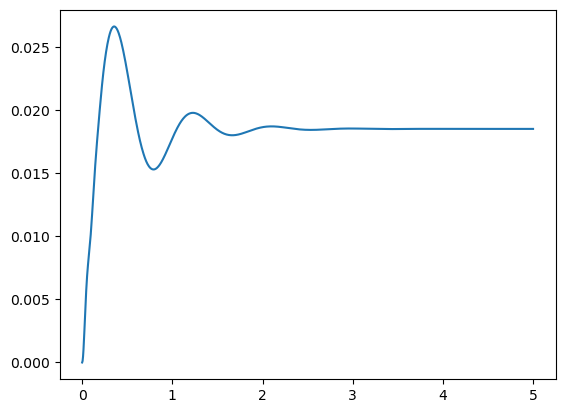

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
# caso A = Tradicional, B = Confort, C = deportivo
M_lista = [300,320,280]
m_lista = [40,45,40]
k1_lista = [18000,15000,30000]
c_lista = [1500,1200,2500]
k2_lista = [180000,160000, 200000]
g = 9.81

caso = 0
M = M_lista[caso]
m = m_lista[caso]
k1 = k1_lista[caso]
c = c_lista[caso]
k2 = k2_lista[caso]

# Función que define el sistema de ecuaciones diferenciales
def f(t,x):
    dxdt = np.zeros(4)
    dxdt[0] = x[1] # z1
    dxdt[1] = (-(k1+k2)*x[0] + k1*x[2] - c*x[1] + c*x[3]+k2*r) / m + g
    dxdt[2] = x[3]
    dxdt[3] = (-k1*x[2] -c*x[3] + k1*x[0] +c*x[1]) / M + g
    return dxdt

# Condiciones iniciales
x0 = [0, 0, 0, 0]  # [x1, x1', x2, x2']
r = 0

# Tiempo de simulación
t_span = (0, 5)

# Resolver el sistema de ecuaciones diferenciales
sol = solve_ivp(f, t_span, x0, t_eval=np.linspace(t_span[0], t_span[1], 1000))
plt.plot(sol.t, sol.y[0], label='x1 (Car Body)')